
*  DSC530-T302 Data Exploration and Analysis (2263-1) 
*  Project
*  Paula Iman
*  Due Week 11

# Project
## NYC Open Data
### SBS Certified Business List

# Preliminary preparation tasks
## 1. Dataset Selection - Small Business Services Certified Business List

a. Adequacy: This data contains about 11,000 records. The data includes necessary variables such as ethnicity, Certification Date, and Borough. The goal is to gain insights about small businesses in New York City, with a particular focus on understanding the experiences of women- and minority-owned businesses in the city. 

b. Data Integrity: This data is from the official NYC government data. As an official database, it lists all legal small business establishments. Data is updated regularly which supports the data integrity and correctness.

Page about the data: https://data.cityofnewyork.us/Business/SBS-Certified-Business-List/ci93-uc8s/about_data

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Using API endpoint URL from SBS Certified Business List site
# website "https://data.cityofnewyork.us/Business/SBS-Certified-Business-List/ci93-uc8s/about_data"
# This is the SODA API Endpoint for the dataset
# Adding ?$limit=20000 because the API returns only 1000 rows by default
url = "https://data.cityofnewyork.us/resource/ci93-uc8s.json?$limit=20000"   

# Getting data using requests
response = requests.get(url)

# Successfull request status is 200. Checking if the response is successful
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print(f"Import was successful. Data includes {len(df)} rows.")
else:
    print(f"Error: {response.status_code}")

Import was successful. Data includes 11294 rows.


In [2]:
# Initial look
df.head()

,account_number,vendor_formal_name,vendor_dba,first_name,last_name,telephone,business_description,certification,cert_renewal_date,ethnicity,...,longitude,community_board,council_district,bin,bbl,census_tract_2020_,neighborhood_tabulation_area_nta_2020_,address2,aggregate_bonding_limit,signatory_to_union_contracts
0,373634,“I AM” EHS Management LLC,“I AM” EHS Management LLC,Kirt,Asson,9147712515,"In 2006, I had the opportunity to join NYC San...",MBE,3/31/2029,BLACK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,377031,000 Architecture PLLC,NaN,Jedy,Lau,2012561092,000 Architecture PLLC is an architectural studio.,MBE,3/31/2030,ASIAN,...,-73.987898,105,2,1017814,1008710068,50,MN0602,NaN,NaN,NaN
2,331157,024 Inc,NaN,Gena,Surphlis,3479035447,024™ is a premium home fragrance brand that de...,"MBE,WBE",04/30/2026;04/30/2026,BLACK,...,-73.821595,210,12,2093860,2051350051,30202,BX1004,#23D,NaN,NaN
3,10003,1 Call Building Maintenance Corp.,NaN,Lorris,Alleyne,3474690806,Our Services include Office Cleaning Carpet cl...,MBE,3/31/2026,BLACK,...,-73.962817,308,35,3027510,3011240022,203,BK0801,NaN,NaN,NaN
4,315255,1 Oak Tasty Deli Inc.,NaN,Santiago,Francisco,2129230700,"1 Oak Tasty Deli supplies food for events, gat...",MBE,4/30/2029,HISPANIC,...,-73.939134,112,10,1063014,1021260001,253,MN1201,NaN,NaN,NaN


In [3]:
# Summary statistics with describe() 
df.describe()

,account_number,vendor_formal_name,vendor_dba,first_name,last_name,telephone,business_description,certification,cert_renewal_date,ethnicity,...,longitude,community_board,council_district,bin,bbl,census_tract_2020_,neighborhood_tabulation_area_nta_2020_,address2,aggregate_bonding_limit,signatory_to_union_contracts
count,11294,11294,1530,11272,11272,11294,11294,11294,8369,11292,...,6876,6876,6876,6838,6838,6876,6876,4394,977,635
unique,11294,11294,1530,5118,7220,11182,11249,10,168,6,...,5703,60,51,5628,5580,1241,203,2460,122,567
top,373634,“I AM” EHS Management LLC,“I AM” EHS Management LLC,Jennifer,Singh,9146650654,Electrical Contractor,MBE,10/31/2030,BLACK,...,-73.949237,105,3,3000000,4004490013,21,MN0502,2nd Floor,1000000,IBEW 3
freq,1,1,1,85,143,4,9,5079,149,3706,...,17,632,450,24,17,93,329,83,75,14


Summary statistics are not useful for this data set. Instead, it is better to use info() to see the headings and if there are null values.

In [4]:
# Taking a look at the column headings and if there are null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11294 entries, 0 to 11293
Data columns (total 54 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   account_number                          11294 non-null  object
 1   vendor_formal_name                      11294 non-null  object
 2   vendor_dba                              1530 non-null   object
 3   first_name                              11272 non-null  object
 4   last_name                               11272 non-null  object
 5   telephone                               11294 non-null  object
 6   business_description                    11294 non-null  object
 7   certification                           11294 non-null  object
 8   cert_renewal_date                       8369 non-null   object
 9   ethnicity                               11292 non-null  object
 10  address1                                11171 non-null  object
 11  ci

At first view, the data set does not have a business establishment date ('date_of_establishment') for each business. This limits our ability to examine the number of minority-owned businesses started each year or decade. Even if we can investigate how many minority businesses with a registered establishment date were established each decade, the count will still overlook businesses that lack a registered establishment date. 

The dataset is also missing attributes for gender. It may be possible to gain insight into how many businesses are operated by women by using a gender-guesser and analyzing the names associated with each account. However, this will not reveal 100% of the genders, as some Western names may be ambiguous and indicate either gender. Also, there are non-Western names that a gender-guesser would have difficulty identifying.

I am interested in examining the number of companies founded by minority owners in each decade, with a particular focus on those established in the past few decades. I am interested in determining whether the number of minority-owned registered businesses in NYC has increased over the past decade. It is also interesting to observe the increasing number of businesses utilizing websites and whether this trend has continued over the past decade. It is also interesting to see when the number of websites per business started to grow. For that reason, we will also investigate previous decades. 

To learn about the volume of the business and have a numeric variable to calculate central tendencies, a variable indicating the volume of the business is needed. 

In [31]:
# Listing the desired columns for EDA
cols_to_keep = ['account_number', 'vendor_formal_name',
                'first_name', 'business_description',
                'certification', 'ethnicity','city',
                'website', 'id6_digit_naics_code', 'largest_value_of_contract',
                'naics_sector', 'naics_subsector', 'naics_title',
                'enrolled_in_passport', 'date_of_establishment',
                'cert_renewal_date', 'signatory_to_union_contracts'
]
# Making sure the columns exist in the data frame and creating a subset
df_subset = df[[c for c in cols_to_keep if c in df.columns]].copy()

# Examining the data values in each column
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11294 entries, 0 to 11293
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   account_number                11294 non-null  object
 1   vendor_formal_name            11294 non-null  object
 2   first_name                    11272 non-null  object
 3   business_description          11294 non-null  object
 4   certification                 11294 non-null  object
 5   ethnicity                     11292 non-null  object
 6   city                          11294 non-null  object
 7   website                       7967 non-null   object
 8   id6_digit_naics_code          11294 non-null  object
 9   largest_value_of_contract     10518 non-null  object
 10  naics_sector                  11294 non-null  object
 11  naics_subsector               11294 non-null  object
 12  naics_title                   11280 non-null  object
 13  enrolled_in_pass

## 2. Data Cleaning and Preparation

a. Handle missing values or outliers: This data set has 800+ establishment dates missing, and the dates are not in standard format.

b. Recoding or encoding of variables: Creating a new column with establishment and renewal years alone.

c. Data transformation is necessary when certain variables are skewed or have extreme values: For this dataset, transformation is not needed.

d. Normalization or Standardization: Creating standard casing for the name and mailing city columns to make sure they look the same. Also, converting the column for union into binary values for clarity.   

In [32]:
# Some dates of establishment are missing. Dropping the rows with missing dates for time analysis
df_subset = df_subset.dropna(subset=['date_of_establishment']).copy()

# The date columns have different formats. Converting the date columns to Datetime
df_subset['date_of_establishment'] = pd.to_datetime(df_subset['date_of_establishment'], errors='coerce')
df_subset['cert_renewal_date'] = pd.to_datetime(df_subset['cert_renewal_date'], errors='coerce')

# Creating a column for years
df_subset['est_year'] = df_subset['date_of_establishment'].dt.year.astype('Int64')
df_subset['renew_year'] = df_subset['cert_renewal_date'].dt.year.astype('Int64')
# df_subset.info()

In [33]:
# Installing gender-guesser to use gender_guesser
!pip install gender-guesser
import gender_guesser.detector as gender
detect = gender.Detector(case_sensitive=False)

# Function to process the first names in the dataframe
def get_gender(name):
    if pd.isna(name):
        return 'unknown'
    # in case there is an initial for the second name, take the first name only
    first_name = str(name).split()[0]
    return detect.get_gender(first_name)
df_subset['gender_estimate'] = df_subset['first_name'].apply(get_gender)

In [34]:
# Check unique values in the 'signatory_to_union_contracts' column
print("Unique values in the 'signatory_to_union_contracts' column:")
print(df_subset['signatory_to_union_contracts'].value_counts(dropna=False))

Unique values in the 'signatory_to_union_contracts' column:
signatory_to_union_contracts
NaN                                                                                                     9822
IBEW 3                                                                                                    14
Electric IBEW 3                                                                                           10
Teamsters 282                                                                                              6
International Brotherhood of Electrical Workers 3                                                          5
                                                                                                        ... 
International Union of Operating Engineers Local 15D, IUOE Local 825                                       1
Op Eng 371, Op Eng 15, Laborers 731                                                                        1
IBEW 456 456                           

The dataset contains 549 distinct union entries, resulting in a highly fragmented structure. 
Some unions, such as the Teamsters and the Electric IBEW, belong exclusively to the construction and trade industries.

In [35]:
# Filling in missing values for the website and for the signatory to the union contract columns
df_subset['first_name'] = df_subset['first_name'].fillna('None')
df_subset['city'] = df_subset['city'].fillna('None')
df_subset['website'] = df_subset['website'].fillna('None')

# Creating standard casing
df_subset['first_name'] = df_subset['first_name'].str.title()
df_subset['city'] = df_subset['city'].str.title()

# Convert 'NaN' type to 0 and 'Yes' to 1 to indicate if a business is unionized.
df_subset['is_union'] = df_subset['signatory_to_union_contracts'].notna()
df_subset['is_union'] = df_subset['is_union'].astype(int)

# Converting NAICS code into int
df_subset['id6_digit_naics_code'] = df_subset['id6_digit_naics_code'].astype(int)

# Converting "largest_value_of_contract' into a number for calculation and cleaning the values and filling NA with 0
df_subset['largest_value_of_contract'] = df_subset['largest_value_of_contract'].astype(str).str.replace(r'[$, ]', '', regex=True)
df_subset['largest_value_of_contract'] = pd.to_numeric(df_subset['largest_value_of_contract'], errors='coerce')
df_subset['largest_value_of_contract'] = df_subset['largest_value_of_contract'].fillna(0)

df_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10433 entries, 1 to 11293
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   account_number                10433 non-null  object        
 1   vendor_formal_name            10433 non-null  object        
 2   first_name                    10433 non-null  object        
 3   business_description          10433 non-null  object        
 4   certification                 10433 non-null  object        
 5   ethnicity                     10431 non-null  object        
 6   city                          10433 non-null  object        
 7   website                       10433 non-null  object        
 8   id6_digit_naics_code          10433 non-null  int32         
 9   largest_value_of_contract     10433 non-null  float64       
 10  naics_sector                  10433 non-null  object        
 11  naics_subsector               104

In [36]:
df_subset.head(7)

,account_number,vendor_formal_name,first_name,business_description,certification,ethnicity,city,website,id6_digit_naics_code,largest_value_of_contract,...,naics_subsector,naics_title,enrolled_in_passport,date_of_establishment,cert_renewal_date,signatory_to_union_contracts,est_year,renew_year,gender_estimate,is_union
1,377031,000 Architecture PLLC,Jedy,000 Architecture PLLC is an architectural studio.,MBE,ASIAN,New York,None,541310,140000.00,...,"Architectural, Engineering, and Related Services",Architectural Services,Yes,2023-07-05,2030-03-31,NaN,2023,2030,unknown,0
2,331157,024 Inc,Gena,024™ is a premium home fragrance brand that de...,"MBE,WBE",BLACK,Bronx,https://www.zerotwofour.com/,453998,20.00,...,Other Miscellaneous Store Retailers,All Other Miscellaneous Store Retailers (excep...,No,2019-02-08,NaT,NaN,2019,<NA>,female,0
3,10003,1 Call Building Maintenance Corp.,Lorris,Our Services include Office Cleaning Carpet cl...,MBE,BLACK,Brooklyn,http://www.1callbuildingmaintenance.com,561720,200000.00,...,Services to Buildings and Dwellings,Janitorial Services,Yes,2004-02-02,2026-03-31,NaN,2004,2026,male,0
4,315255,1 Oak Tasty Deli Inc.,Santiago,"1 Oak Tasty Deli supplies food for events, gat...",MBE,HISPANIC,New York,None,722511,2056.25,...,Restaurants and Other Eating Places,Full-Service Restaurants,Yes,2012-03-31,2029-04-30,NaN,2012,2029,male,0
7,308309,1 We Build Environments Corp,Alla,1 We Build Environments is a company which doe...,WBE,NON-MINORITY,New York,http://www.wbe.nyc,236117,350150.00,...,Residential Building Construction,New Housing For-Sale Builders,Yes,2018-08-23,NaT,NaN,2018,<NA>,female,0
8,10015,1-800 Mr. Rubbish Inc.,Abeir,1-800 Mr. Rubbish is a garbage removal and dem...,"MBE,WBE",ASIAN,Brooklyn,http://www.1800mrrubbish.com,562111,64500.00,...,Waste Collection,Solid Waste Collection,Yes,2013-08-08,NaT,NaN,2013,<NA>,unknown,0
9,10007,10 November LLC,Alfred,10 November LLC is a subcontractor that does c...,MBE,HISPANIC,New Rochelle,http://www.10novgroup.com,236220,69865300.00,...,Nonresidential Building Construction,Commercial and Institutional Building Construc...,Yes,2014-02-28,2028-12-31,NaN,2014,2028,male,0


# Exploratory Data Analysis (EDA) Tasks  

## 1.	Describe the Variable Characteristics with Summary Statistics  
	- Provide a description of the variables you are using in this project.  
All the needed variables are now formatted for use in analysis. 

'account_number': Vendor Number

'vendor_formal_name': Formal name of the company

'first_name': First name of the company's contact person. This may not be the owner of the company. 

'business_description': A brief description of the type of service provided.

'certification': Type of certification the company qualified for

'cert_renewal_date': Certification renewal date

'ethnicity': Ethnicity of the Company owners

'city': City where the company is located.

'website': Company website

'id6_digit_naics_code': North American Industry Classification System (NAICS) code that identifies the type of business

'largest_value_of_contract': Value of the contract

'naics_sector': Industry sector

'naics_subsector': NAICS Subsector

'naics_title': Type of business

'enrolled_in_passport': Enrollment in the NYC's Procurement and Sourcing Solutions Portal

'date_of_establishment': Date the company was established

'signatory_to_union_contracts': Signatory to Union contracts

## 2.	Conduct Univariate Analysis 

a.	Calculate descriptive statistics (mean, median, mode, variance, skewness, kurtosis) of the key variables in your dataset

In [11]:
contract_stats = df_subset['largest_value_of_contract'].agg(['mean', 'median', 'var', 'skew', 'kurt'])
contract_mode = df_subset['largest_value_of_contract'].mode()[0]

print("Calculated desrcriptive statistics for Largest Value of Contract:")
print(contract_stats.map('{:.3f}'.format))
print(f' mode: {contract_mode}')

Calculated desrcriptive statistics for Largest Value of Contract:
mean                5742574.503
median                66893.580
var       12318832186861360.000
skew                     52.426
kurt                   3526.352
Name: largest_value_of_contract, dtype: object
 mode: 0.0


High skewness indicates that a few companies hold significantly larger contracts compared to the rest of the businesses.
Additionally, a significantly higher average than the median indicates that there are some large outliers that raise the average across all businesses.
Mode is 0. Many of the companies may not have contracts yet. 
Note: The skewness of 52.20 will influence calculations later in this project.

In [12]:
# Establishment year stats
print("Establishment Year Stats:")
est_year_stats = df_subset['est_year'].agg(['mean', 'median', 'skew', 'kurt'])
print(est_year_stats.round(0).astype(int))

Establishment Year Stats:
mean      2011
median    2014
skew        -2
kurt         7
Name: est_year, dtype: int32


The average year is 2011, meaning that the average business is about 15 years old (mean 2011). 
Since the median is higher, there are more newer companies. However, there are a few older companies that are still listed in the public records.

b.	Create a visualization of the key variables to examine distribution or patterns 

i.	Consider adding histogram, box plots, or density plots to visualize the distribution of numerical variables, and bar charts for categorical variables. 


In [13]:
# Showing the actual number of union vs non-union businesses
union_counts = df_subset['is_union'].value_counts()
print("Total Unionized Businesses:", union_counts.get(1, 0))
print("Total Non-Union Businesses:", union_counts.get(0, 0))

# Proportion of Unionized Businesses
print(f"\nUnionized Proportion: {df_subset['is_union'].mean():.2%}")

Total Unionized Businesses: 611
Total Non-Union Businesses: 9822

Unionized Proportion: 5.86%


In [14]:
# Since there are 617 unionized businesses, it is worth finding out if they also have bigger contracts.
# Grouping by the union status and finding the median value for each.
is_union_comparison = df_subset.groupby('is_union')['largest_value_of_contract'].median()

print("The Median Contract Value for unionized and Non-Union businesses")
print(f"Non_Union: ${is_union_comparison[0]:,.2f}")
print(f"Unionized: ${is_union_comparison[1]:,.2f}")
                                        

The Median Contract Value for unionized and Non-Union businesses
Non_Union: $54,645.00
Unionized: $1,979,600.00


Result shows that unionized businesses have much larger contracts. 

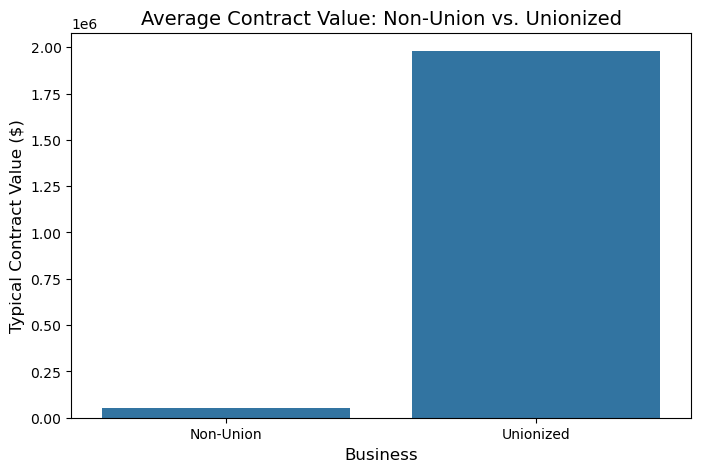

In [15]:
# Creating a Bar Chart to visualize the difference
plt.figure(figsize=(8, 5))
sns.barplot(x='is_union', y='largest_value_of_contract', data=df_subset, estimator='median', errorbar=None, legend=False)

# Adding simple labels
plt.title('Average Contract Value: Non-Union vs. Unionized', fontsize=14)
plt.xlabel('Business', fontsize=12)
plt.ylabel('Typical Contract Value ($)', fontsize=12)
plt.xticks([0, 1], ['Non-Union', 'Unionized'])

# Drawing the plot
plt.show()

In [16]:
#Finding out how the values in the column 'gender_estimate.'
print(df_subset['gender_estimate'].value_counts())

gender_estimate
female           4367
male             3210
unknown          1985
mostly_female     346
mostly_male       335
andy              190
Name: count, dtype: int64


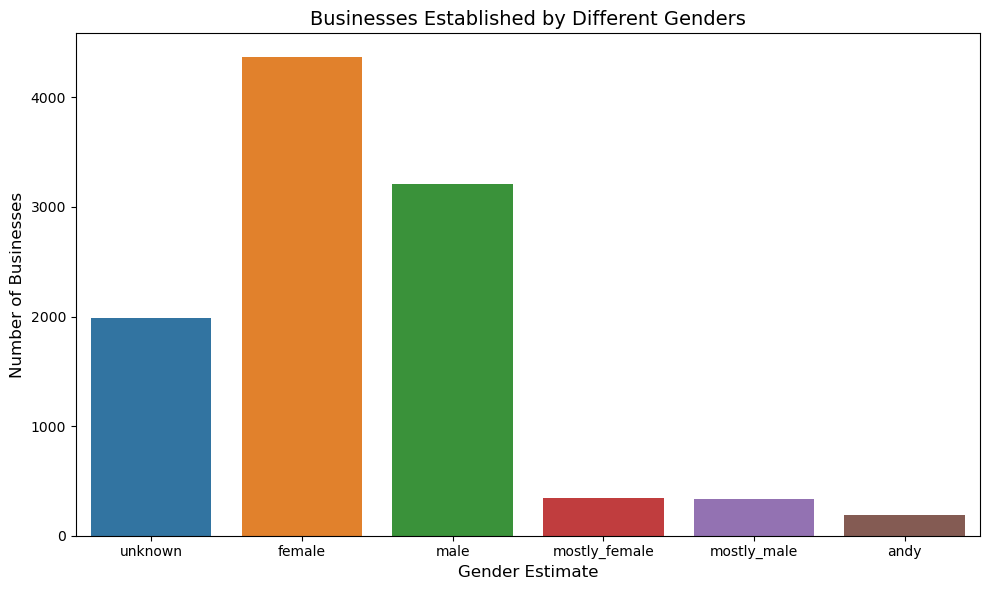

In [17]:
# visualizing the businesses started by different genders
# Since names would overlap, setting the figure size
plt.figure(figsize=(10, 6))

# Creating the plot
sns.countplot(data=df_subset, x='gender_estimate', hue='gender_estimate', legend=False)

# labels and title
plt.title('Businesses Established by Different Genders', fontsize=14)
plt.xlabel('Gender Estimate', fontsize=12)
plt.ylabel('Number of Businesses', fontsize=12)

# Showing the plot
plt.tight_layout() # This ensures nothing gets cut off
plt.show()

In [18]:
#Finding out the values in the column 'ethnicity.'
print(df_subset['ethnicity'].value_counts())

ethnicity
BLACK              3357
NON-MINORITY       2760
ASIAN              2372
HISPANIC           1925
NATIVE AMERICAN      15
/A                    2
Name: count, dtype: int64


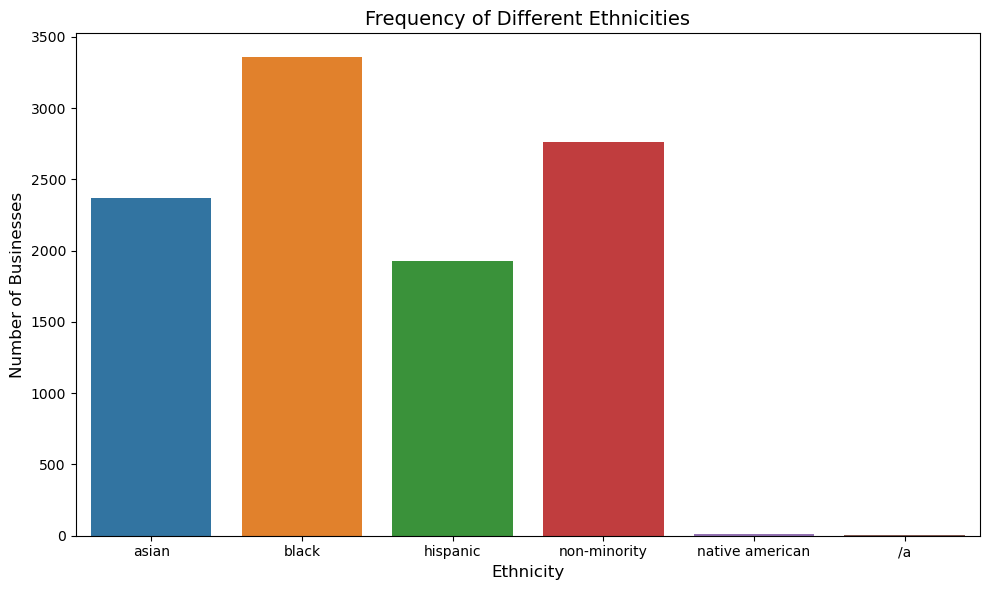

In [19]:
# visualizing the number of ethnicities
# Setting the figure size
plt.figure(figsize=(10, 6))

# Creating the plot
sns.countplot(
    data=df_subset.assign(ethnicity=df_subset['ethnicity'].str.lower()), 
    x='ethnicity', 
    hue='ethnicity', 
    legend=False)

# labels and title
plt.title('Frequency of Different Ethnicities', fontsize=14)
plt.xlabel('Ethnicity', fontsize=12)
plt.ylabel('Number of Businesses', fontsize=12)

# Showing the plot
plt.tight_layout() # This ensures nothing gets cut off
plt.show()

In [20]:
# Finding out what the 10 oldest businesses are in this data set
oldest_businesses = df_subset.nsmallest(10, 'date_of_establishment')
# Finding out what the 10 newest businesses are in this data set
newest_businesses = df_subset.nlargest(10, 'date_of_establishment')
# Displaying the 10 oldest and 10 newest businesses.
display(pd.concat([oldest_businesses, newest_businesses])[['account_number', 'vendor_formal_name', 'first_name', 'ethnicity', 'gender_estimate', 'city', 'date_of_establishment', 'cert_renewal_date']])

,account_number,vendor_formal_name,first_name,ethnicity,gender_estimate,city,date_of_establishment,cert_renewal_date
7134,14711,"National Reprographics, Inc.",Ellen,NON-MINORITY,female,New York,1904-06-01,NaT
2683,3892,"D. Parker and Sons, Inc.",Pamela,BLACK,female,Riverhead,1911-12-31,2028-06-30
10540,4462,"Turtle & Hughes, Inc.",Jayne,NON-MINORITY,female,Linden,1923-01-01,NaT
4459,3573,"Harry Brainum Jr., Inc.",Jarett,NON-MINORITY,unknown,Bronx,1924-05-12,NaT
211,309342,"A.J. McNulty & Company, Inc.",Elizabeth,NON-MINORITY,female,Maspeth,1925-01-01,NaT
6188,103273,"Lozier, Inc.",Uzma,ASIAN,unknown,Whitestone,1925-12-11,NaT
8353,100154,R. Baker & Son All Industrial Services Inc. of NJ,Arthur,HISPANIC,male,Marlboro,1935-01-01,NaT
194,10136,"A. Alport & Son, Inc.",Dory,NON-MINORITY,female,So. Fallsburg,1936-01-01,NaT
8689,2584,"Robinson Aerial Surveys, Inc.",Carlos,HISPANIC,male,Hackettstown,1936-01-01,2026-09-30
6773,14495,"Miller Advertising Agency, Inc.",Nicole,NON-MINORITY,female,New York,1936-07-13,NaT


Among registered businesses, female ownership exceeds male ownership. 
I want to see how the ownership percentage has changed since the oldest registration was made in 1904 til the latest registration in 2025.

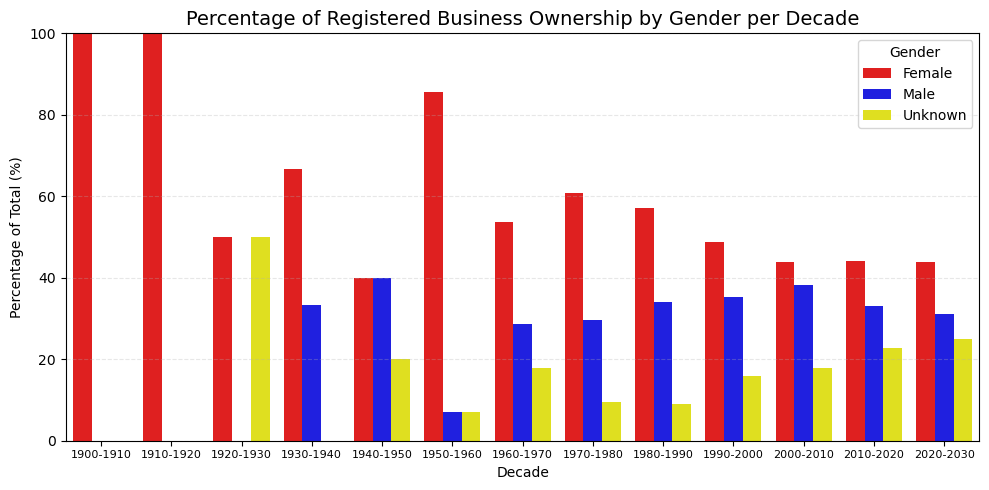

In [38]:
# Creating gender groups by combining them into three categories: female and mostly female, male and mostly male, and unknown.
# There was a value error working with original df_subset. Ensuring that there are no NA values first.
# Ensure we are working with a fresh copy and drop rows missing vital info
# We need the establishment year and gender to make this chart work
df_clean = df_subset.dropna(subset=['date_of_establishment', 'gender_estimate']).copy()

# Create the Year and Decade columns (Handling the .0 decimal issue)
df_clean['est_year'] = df_clean['date_of_establishment'].dt.year.astype(int)
df_clean['decade_start'] = (df_clean['est_year'] // 10) * 10
df_clean['decade_label'] = df_clean['decade_start'].astype(str) + '-' + (df_clean['decade_start'] + 10).astype(str)

# Creating three gender categories.
gender_map = {
    'female': 'Female', 'mostly_female': 'Female',
    'male': 'Male', 'mostly_male': 'Male',
    'unknown': 'Unknown', 'andy': 'Unknown'
}
df_clean['gender_group'] = df_clean['gender_estimate'].map(gender_map)

# Percentages count by decade and gender
counts = df_clean.groupby(['decade_start', 'decade_label', 'gender_group']).size().reset_index(name='count')
# Total businesses per decade
totals = df_clean.groupby('decade_start').size().reset_index(name='total')

# Merge counts and totals to do the math
decade_perc = pd.merge(counts, totals, on='decade_start')
decade_perc['Percentage'] = (decade_perc['count'] / decade_perc['total']) * 100

# Bar Chart
plt.figure(figsize=(10, 5))
color_map = {'Female': 'red', 'Male': 'blue', 'Unknown': 'yellow'}

sns.barplot(
    data=decade_perc.sort_values('decade_start'), 
    x='decade_label', 
    y='Percentage', 
    hue='gender_group', 
    palette=color_map,
    hue_order=['Female', 'Male', 'Unknown']
)

# Visual Clean-up
plt.title('Percentage of Registered Business Ownership by Gender per Decade', fontsize=14)
plt.ylabel('Percentage of Total (%)', fontsize=10)
plt.xlabel('Decade', fontsize=10)
plt.ylim(0, 100)
plt.xticks(fontsize=8)
plt.legend(title='Gender', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
                 



At first glance, it appears that no male-owned businesses were registered until the 1930s. 
Looking at the first 10 businesses listed above, this is correct. 
This data shows that there have always been more women-owned registered businesses. There must have been businesses founded by men, but for some reason, they were not registered. If they were registered, they did not remain open for recording in this data. However, that is out of the scope of this data project.

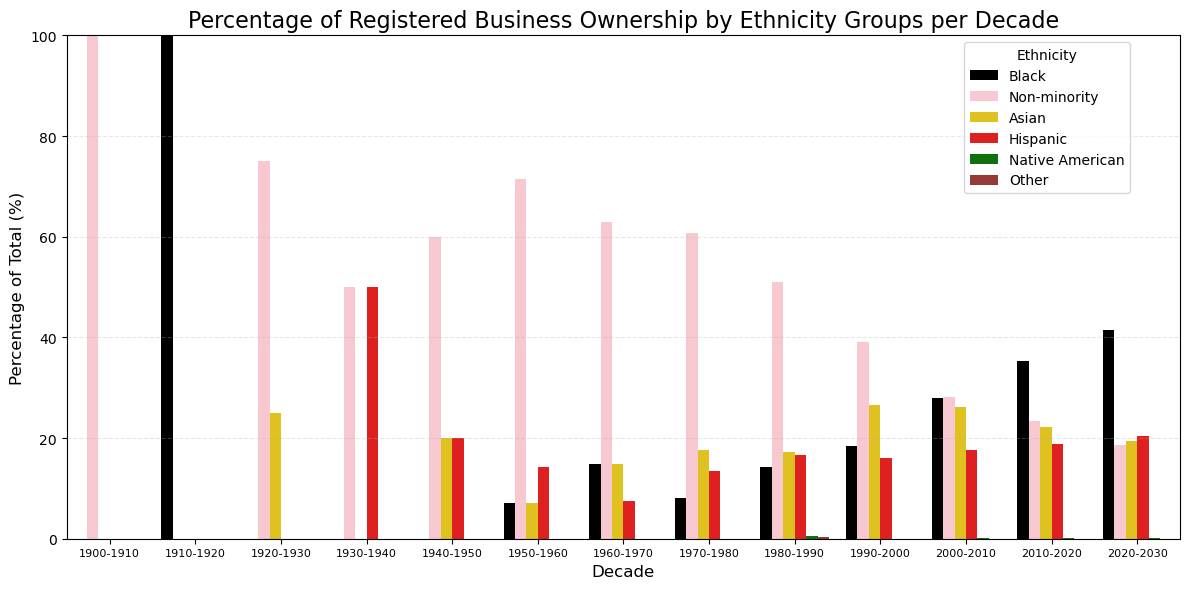

In [39]:
#Creating the same kind of chart using 'ethnicity.'
# Using df_clean to avoid NA values
df_clean = df_subset.dropna(subset=['date_of_establishment', 'ethnicity']).copy()

# Aranging the years and lables
df_clean['est_year'] = df_clean['date_of_establishment'].dt.year.astype(int)
df_clean['decade_start'] = (df_clean['est_year'] // 10) * 10
df_clean['decade_label'] = df_clean['decade_start'].astype(str) + '-' + (df_clean['decade_start'] + 10).astype(str)

# Creating Ethnicity Map just like above
# The ethnicities are in upper case. Converting the ethnicities to upper case to match the data in the database.
df_clean['ethnicity_upper'] = df_clean['ethnicity'].str.upper().str.strip()

ethnicity_map = {
    'BLACK': 'Black', 
    'NON-MINORITY': 'Non-minority',
    'ASIAN': 'Asian', 
    'HISPANIC': 'Hispanic',
    'NATIVE AMERICAN': 'Native American'
}

# Apply the map and fill anything else with 'Other.'
df_clean['ethnicity_group'] = df_clean['ethnicity_upper'].map(ethnicity_map).fillna('Other')

# Percentage calculation
counts = df_clean.groupby(['decade_start', 'decade_label', 'ethnicity_group']).size().reset_index(name='count')
totals = df_clean.groupby('decade_start').size().reset_index(name='total')

decade_perc = pd.merge(counts, totals, on='decade_start')
decade_perc['Percentage'] = (decade_perc['count'] / decade_perc['total']) * 100

# Plotting Bar chart
plt.figure(figsize=(12, 6))
color_map = {
    'Black': 'black', 
    'Non-minority': 'pink', 
    'Asian': 'gold', 
    'Hispanic': 'red', 
    'Native American': 'green', 
    'Other': 'brown' 
}

sns.barplot(
    data=decade_perc.sort_values('decade_start'), 
    x='decade_label', 
    y='Percentage', 
    hue='ethnicity_group', 
    palette=color_map,
    hue_order=['Black', 'Non-minority', 'Asian', 'Hispanic', 'Native American', 'Other']
)

plt.title('Percentage of Registered Business Ownership by Ethnicity Groups per Decade', fontsize=16)
plt.ylabel('Percentage of Total (%)', fontsize=12)
plt.xlabel('Decade', fontsize=12)
plt.ylim(0, 100)
plt.xticks(fontsize=8)
plt.legend(title='Ethnicity', bbox_to_anchor=(0.80, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Data show that, among still-existing registered businesses, only non-minority businesses were registered during the first decade, and only Black-owned businesses were registered during the second decade. 
There may be mistakes in this data, or some data may be missing or removed due to NA fields. 
However, since the 1950s, the percentage of minority-owned registered businesses, especially black-owned businesses, has grown, whereas the percentage of non-minority owned registered businesses has declined. 

ii.	If you have to handle outliers/skewness, it is important to visualize outliers through boxplots or scatterplots and then explain the methods used, such as why trimming or transformation was applied (or why not).  

The 'largest_value_of_contract' variable has the most skewness in this dataset. A box plot will help visualize how skewed this data is. 

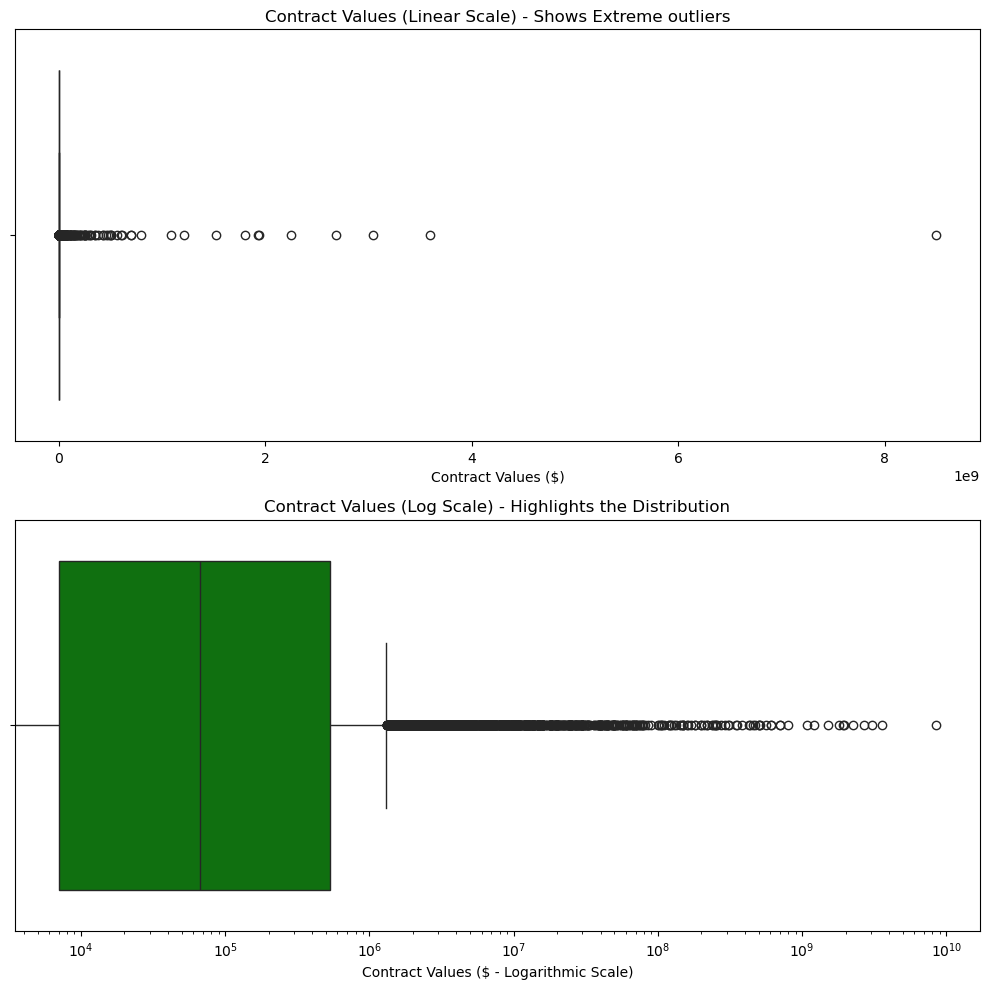

In [40]:
# creating two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Creating linear scale box plot. It reveals the extreme nature
sns.boxplot(ax=axes[0], x=df_subset['largest_value_of_contract'], color = 'green')
axes[0].set_title('Contract Values (Linear Scale) - Shows Extreme outliers', fontsize = 12)
axes[0].set_xlabel('Contract Values ($)')

# Creating log scale box plot. It shows distribution better
sns.boxplot(ax=axes[1], x=df_subset['largest_value_of_contract'], color = 'green')
axes[1].set_xscale('log')
axes[1].set_title('Contract Values (Log Scale) - Highlights the Distribution', fontsize = 12)
axes[1].set_xlabel('Contract Values ($ - Logarithmic Scale)')

plt.tight_layout()
plt.show()

The first plot primarily shows the outliers stretching out, and the main box appears as a thin line at the beginning. The plot shows right or positive skew. There are some companies that have substantially larger contracts than those of the middle 50% of companies. The plot clearly shows a few large outliers. 
The Log Scale plot squeezes the high values and shows the bottom of the middle 50% of the businesses. The large outliers are still clearly visible.

A scatter plot can show if there is a pattern between the age of the business and the contract size. A log-scale plot will prevent all the dots from clumping at the bottom. 

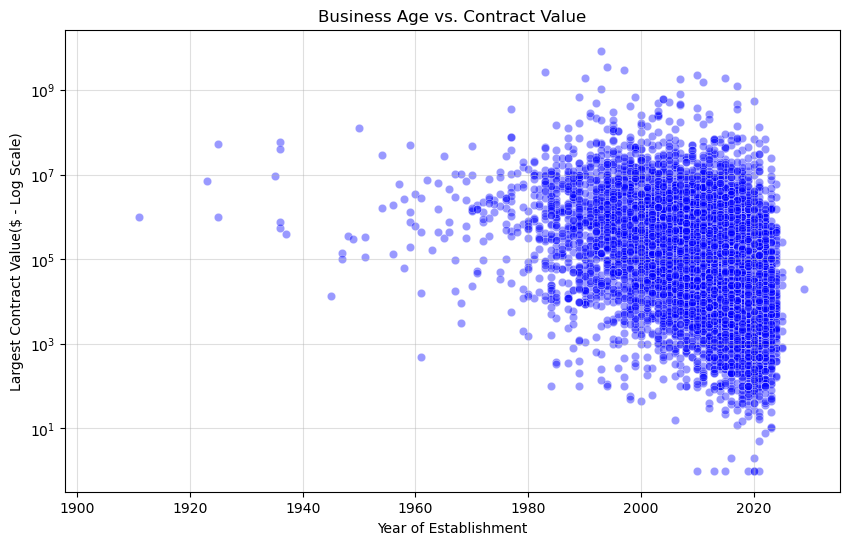

In [41]:
plt.figure(figsize=(10,6))

# Plotting establisment year vs. contract size
sns.scatterplot(data=df_subset, x='est_year', y='largest_value_of_contract', alpha=0.4, color = 'blue')

# using log-scale for y axes
plt.yscale('log')

plt.title('Business Age vs. Contract Value', fontsize=12)
plt.xlabel('Year of Establishment')
plt.ylabel('Largest Contract Value($ - Log Scale)')
plt.grid(True, which='both', ls='-', alpha=0.4)

plt.show()
           

The funnel shape shows that the few older companies have larger contracts. Companies established since the 1980s have more variability in their largest contract sizes.

iii.	You can also visualize missing data (e.g., using a heatmap) to identify patterns in missingness and determine if it is critical.

Several variables had missing data. Especially, many renewal dates were missing. In the original data, the variable 'signatory_to_union_contracts' contained data only for businesses with union contracts. The newly created field 'is_union' is assigned a value of 0 for any business that is not signed to a union contract and therefore no longer has missing values. 

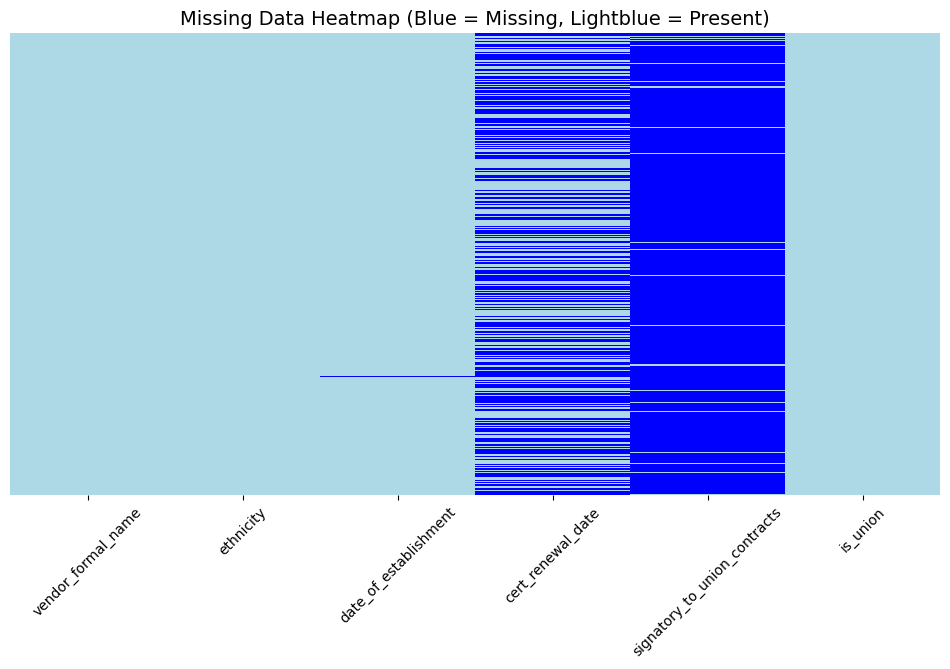

In [42]:
# Selecting some columns to experiment with heat map
# Include columns with high, medium, and low missing values
from matplotlib.colors import ListedColormap # Using Listed colormap to use in the plot.
cols_to_check = ['vendor_formal_name', 'ethnicity', 'date_of_establishment', 
                 'cert_renewal_date', 'signatory_to_union_contracts', 'is_union']

plt.figure(figsize=(12, 6))

# Creating the heatmap using Seaborn heatmap.
# .isnull() turns data into True (1) for missing and False (0) for present
my_colors = ListedColormap(['lightblue', 'blue'])
sns.heatmap(df_subset[cols_to_check].isnull(), yticklabels=False, cbar=False, cmap=my_colors)

plt.title('Missing Data Heatmap (Blue = Missing, Lightblue = Present)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

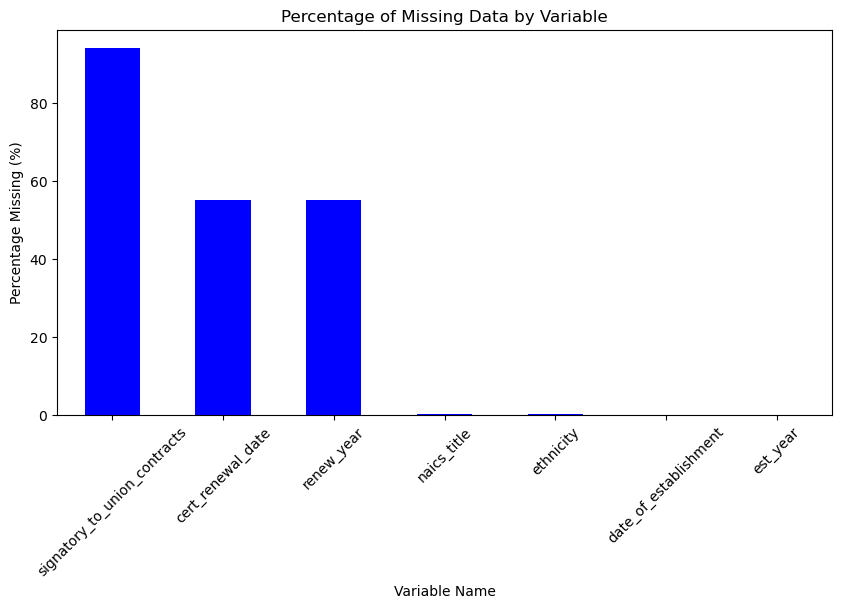

In [43]:
# Creating a bar plot showing the percentage of missing values
# Calculate the percentage of missing values
missing_perc = df_subset.isnull().mean() * 100

# Plot only columns that have at least some missing data
plt.figure(figsize=(10, 5))
missing_perc[missing_perc > 0].sort_values(ascending=False).plot(kind='bar', color='blue')

plt.title('Percentage of Missing Data by Variable', fontsize=12)
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Variable Name')
plt.xticks(rotation=45)
plt.show()

Only a small number of all businesses were unionized. Most businesses were not signatories to union contracts. The certification renewal year was created based on the certification renewal date. Many new companies had not yet renewed their certifications, and some older companies had most likely closed, even if they were still listed in the database. Most companies had data on ethnicity, title, and establishment date. The bar plot shows that only a few data points were missing. 

In [44]:
#Creating a new dataframe with the date of establishment as the index
# Dropping rows with missing data to ensure the index is clean.
# Since the data does not show a substantial amount of businesses before 1960 or after 2020, filtering data for the years 1960-2020
df_filtered = df_subset[(df_subset['date_of_establishment'] >= '1960-01-01') & (df_subset['date_of_establishment'] < '2021-01-01')].copy()

df_timeline = df_filtered[['date_of_establishment', 'ethnicity', 'gender_estimate', 'city']]
df_timeline = df_timeline.set_index('date_of_establishment').sort_index()
#Creating a "dummy" column for calculations showing 1 for each established business
df_timeline['count'] = 1
print(df_timeline.head(), df_timeline.tail())

                          ethnicity gender_estimate           city  count
date_of_establishment                                                    
1960-01-05                      NaN            male       New York      1
1960-05-31             NON-MINORITY          female         Nanuet      1
1961-01-01             NON-MINORITY          female       Brooklyn      1
1961-06-02             NON-MINORITY            male       Brooklyn      1
1961-08-24             NON-MINORITY          female  Staten Island      1                           ethnicity gender_estimate      city  count
date_of_establishment                                               
2020-12-30                    BLACK          female  Brooklyn      1
2020-12-30                    BLACK         unknown  Brooklyn      1
2020-12-31                    BLACK         unknown     Bronx      1
2020-12-31             NON-MINORITY          female   Maspeth      1
2020-12-31                 HISPANIC            male     Bronx      1

In [45]:
#Creating cumulative growth total for ethnicity
# Normalizing the column 'ethnicity' to lowercase first to create matching plots
df_timeline['ethnicity'] = df_timeline['ethnicity'].str.lower()
timeline_ethnicity = df_timeline.groupby(['ethnicity']).resample('Y')['count'].sum().fillna(0)
growth_by_ethnicity = timeline_ethnicity.groupby(level=0).cumsum().reset_index()
#Creating cumulative growth total for gender
timeline_gender = df_timeline.groupby(['gender_estimate']).resample('Y')['count'].sum().fillna(0)
growth_by_gender = timeline_gender.groupby(level=0).cumsum().reset_index()
                                       

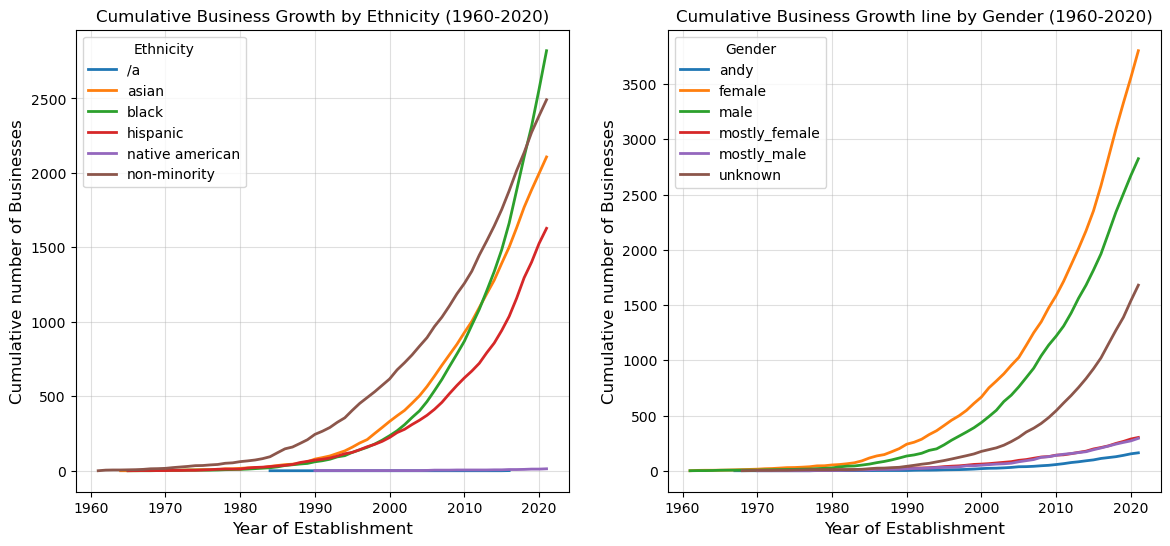

<Figure size 1400x800 with 0 Axes>

In [46]:
#Creating subplots to view growth by ethnicity and gender side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Subplot 1 - ethnicity
plt.figure(figsize=(14,8))

sns.lineplot(ax=axes[0], 
             data=growth_by_ethnicity,
             x='date_of_establishment',
             y='count',
             hue='ethnicity',
             linewidth=2)
axes[0].set_title('Cumulative Business Growth by Ethnicity (1960-2020)', fontsize=12)
axes[0].set_xlabel('Year of Establishment', fontsize = 12)
axes[0].set_ylabel('Cumulative number of Businesses', fontsize=12)
axes[0].grid(True, alpha=0.4)
axes[0].legend(title='Ethnicity', loc='upper left')

#Subplot 2 - gender_estimate
sns.lineplot(ax=axes[1], data=growth_by_gender,
             x='date_of_establishment',
             y='count',
             hue='gender_estimate',
             linewidth=2)
axes[1].set_title('Cumulative Business Growth line by Gender (1960-2020)', fontsize=12)
axes[1].set_xlabel('Year of Establishment', fontsize = 12)
axes[1].set_ylabel('Cumulative number of Businesses', fontsize=12)
axes[1].grid(True, alpha=0.4)
axes[1].legend(title='Gender', loc='upper left')

plt.tight_layout()
plt.show()

"Both plots indicate a significant turning point around 1980, where business registrations accelerated across all ethnic and gender groups. During Mayor Koch’s tenure, Executive Order 50 (E.O. 50) was issued, requiring all city contractors to obtain a Certificate of Approval to ensure compliance with equal opportunity standards. Before this mandate, formal registrations in the city’s database were nearly non-existent.

Following the implementation of these registration requirements, the number of Black-owned businesses soared, with growth rates that outpaced those of other ethnic groups in the initial decades.

In the second chart, we observe that female-owned business registrations grew faster than any other gender category. The 'Unknown' gender category (represented by the brown line) is included to maintain data transparency, accounting for registrations where the owner's gender was not specified or could not be determined."

Reference
NYC Open Data, November 8, 2025, Small Business Services (SBS) Equal Employment Opportunity (EO50) Certified Businesses 
https://catalog.data.gov/dataset/unique-businesses-that-received-eo50-certificate-of-approval-from-sbs#:~:text=This%20dataset%20contains%20a%20list,1980%20during%20Mayor%20Koch's%20tenure.

## 3.	Conduct Bivariate Analysis  
a.	Calculate covariance and correlation

i.	Utilize Pearson correlation for continuous values.  
ii.	For categorical variables, you could explore additional methods like Spearman rank correlation (Optional)  


In [47]:
# Choosing the numeric columns for calculating Covariance and correlation
numeric_cols = df_subset[['largest_value_of_contract', 'est_year', 'is_union']]

# Covariance Matrix
cov_matrix = numeric_cols.cov()

print("Covariance Matrix")
print(cov_matrix.round(3))


Covariance Matrix
                           largest_value_of_contract      est_year    is_union
largest_value_of_contract               1.231883e+16 -6.105636e+07  965649.769
est_year                               -6.105636e+07  1.144760e+02      -0.520
is_union                                9.656498e+05 -5.200000e-01       0.055


A significant positive covariance between unionization and the most considerable contract value suggests that the unionized companies secure higher-value contracts. Union-signatory businesses typically secure larger-scale projects. 
The negative covariance between establishment year and unionization indicates that the newer companies are less likely to be unionized than the older ones. 
Similarly, the negative covariance between establishment year and value suggests that older, more established companies, with a higher rate of unionization, tend to hold larger contracts.

In [48]:
# Pearson Correlation Matrix
corr_matrix = numeric_cols.corr(method='pearson')

print("Pearson Correlation Matrix")
print(corr_matrix.round(3))


Pearson Correlation Matrix
                           largest_value_of_contract  est_year  is_union
largest_value_of_contract                      1.000    -0.051     0.037
est_year                                      -0.051     1.000    -0.207
is_union                                       0.037    -0.207     1.000


The Correlation Matrix shows the same information. Newer companies typically have smaller contract values and less unionization compared to older, unionized companies. 

In [49]:
# Spearman Correlation Matrix
spearman_corr_matrix = numeric_cols.corr(method='spearman')
print("Spearman Correlation Matrix")
print(spearman_corr_matrix.round(3))

Spearman Correlation Matrix
                           largest_value_of_contract  est_year  is_union
largest_value_of_contract                      1.000    -0.366     0.258
est_year                                      -0.366     1.000    -0.185
is_union                                       0.258    -0.185     1.000


Spearman's correlation between unionization and contract value is more significant than Pearson's correlation. 
There is a monotonic relationship: as unionization status moves from 0 to 1, the rank of the contract value consistently rises.

b.	Create visualization 

i.	You may visualize bivariate relationships with scatter plots, pair plots, or heatmaps for correlation matrices.  
ii.	You can create advanced visualization with Seaborn (Optional)  

In [50]:
#Re-map the Ethnicity groups into the main dataframe
ethnicity_map = {
    'BLACK': 'Black', 
    'NON-MINORITY': 'Non-minority',
    'ASIAN': 'Asian', 
    'HISPANIC': 'Hispanic',
    'NATIVE AMERICAN': 'Native American'
}
# Convert to upper case to ensure matches, then map
df_subset['ethnicity_group'] = df_subset['ethnicity'].str.upper().str.strip().map(ethnicity_map).fillna('Other')

#Re-map the Gender groups into the main dataframe
gender_map = {
    'female': 'Female', 'mostly_female': 'Female',
    'male': 'Male', 'mostly_male': 'Male',
    'unknown': 'Unknown', 'andy': 'Unknown'
}
df_subset['gender_group'] = df_subset['gender_estimate'].map(gender_map)

#Creating cross-tab between ethnicity groups and gender groups
gender_ethnicity_ct = pd.crosstab(df_subset['ethnicity_group'], df_subset['gender_group'])

print("Crosstab between Gender and Ethnicity")
display(gender_ethnicity_ct)

Crosstab between Gender and Ethnicity


gender_group,Female,Male,Unknown
ethnicity_group,,,
Asian,481,964,927
Black,1185,1321,851
Hispanic,664,1033,228
Native American,4,11,0
Non-minority,2377,214,169
Other,2,2,0


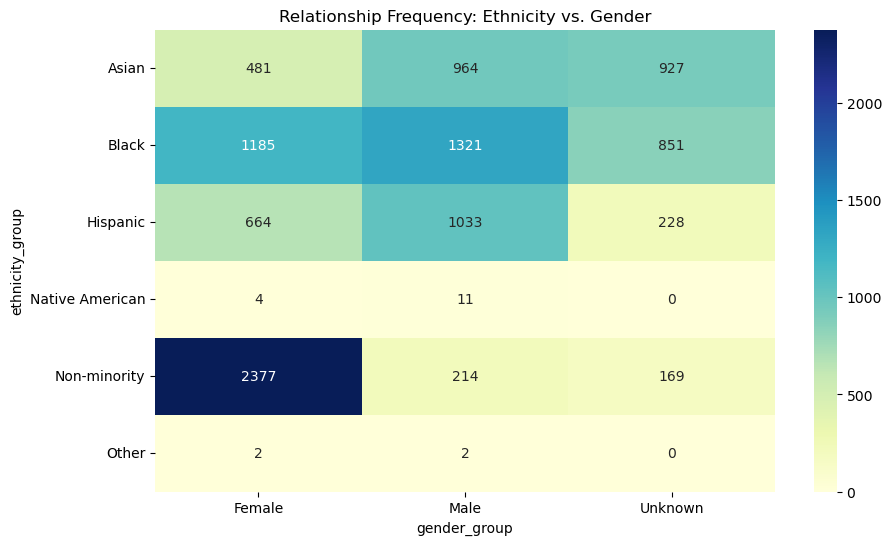

In [51]:
#Visualizing with a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(gender_ethnicity_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Relationship Frequency: Ethnicity vs. Gender')
plt.show()


## 4.	Test Statistics  
a.	Develop a hypothesis and select the appropriate test statistics based on your data.


From earlier steps, it was discovered that there are more female-owned registered businesses than male-owned. Another discovery showed that unionized businesses have larger contracts than non-unionized businesses.

## Hypothesis test for Gender and Ethnicity (Chi-Squared)

### Hypothesis

Null Hypothesis(H0): Registered business ownership gender is independent of ethnicity, and any difference is due to random chance.

Alternative Hypothesis (H1): There is an association between ethnicity and registered business owner gender. Some ethnic groups have higher or lower rates of female ownership.

Test Statistics: Chi-squared test for independence.

### Assumptions and data check

1. both gender_group and ethnicity_group are categorical.
2. Each row is a unique business, and observations are independent.
3. All cells in the crosstab have a count >+5 based on the 10,455 rows of data.

### Interpretation of Results
- If p-value < 0.05: reject H0. Conclusion is that the ownership patterns differ by ethnicity.
- If p-value > 0.05: fail to reject H0 concluding that the gender split is consistent across all ethnic groups.



In [52]:
# Statistical Test (Chi-Square)
from scipy.stats import chi2_contingency
chi2, p_value, dof, ex = chi2_contingency(gender_ethnicity_ct)
print("--- Chi-Squared Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value:             {p_value:.4f}")
print(f"Degrees of Freedom:  {dof}")

#Interpreting values
print("\nInterpretation")
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis.")
    print("There is a statistically significant relationship between ethnicity and gender ownership.")
else:
    print("\nConclusion: Fail to Reject the Null Hypothesis.")
    print("Ownership patterns appear to be independent of ethnicity.")

--- Chi-Squared Test Results ---
Chi-Square Statistic: 3093.7064
P-value:             0.0000
Degrees of Freedom:  10

Interpretation
Conclusion: Reject the Null Hypothesis.
There is a statistically significant relationship between ethnicity and gender ownership.


P-value is significant and shows that female-owned businesses in the dataset are not evenly spread. Previously, the heatmap showed that there is a much larger population of non-minority female business owners compared to other groups.

## Hypothesis test for Union vs. Contract Value (T-test)

### Hypothesis
Null Hypothesis (H0): There is no difference in the average contract value between unionized and non-unionized businesses.

Alternative Hypothesis (H1): Unionized businesses have significantly different value compared to non-unionized businesses.

Test Statistics: Two-sample T-test (independent samples)

### Assumptions and Data Check
1. Contract values are continuous.
2. The values are independent.
3. Normality: The contract data is extremely skewed (skewness 52+). As a result, the data does not meet the normality requirement.
   Since the data are not normal, it is better to use a Log Transformation of the contract values instead of a regular t-test.


### Interpretation

- If p-value < 0.05: reject H0. The conclusion is that union membership predicts contract prices.
- If p-value > 0.05: fail to reject H0, concluding that there is no difference if the business is unionized.


In [53]:
# Using ttest_ind from scipy.stats
from scipy.stats import ttest_ind

#Using log values due to high skewness
union_vals = np.log1p(df_subset[df_subset['is_union'] ==1]['largest_value_of_contract'])
non_union_vals = np.log1p(df_subset[df_subset['is_union'] ==0]['largest_value_of_contract'])

t_stat, p_val = ttest_ind(union_vals, non_union_vals)
print(f"P-value:  {p_val: .5f}")

#Interpreting values
print("\nInterpretation")
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis.")
    print("There is a statistically significant relationship between unionization and the value of the largest contracts.")
else:
    print("\nConclusion: Fail to Reject the Null Hypothesis.")
    print("The contract values seem to be independent from unionization.")

P-value:   0.00000

Interpretation
Conclusion: Reject the Null Hypothesis.
There is a statistically significant relationship between unionization and the value of the largest contracts.


## Cohen's d
Since the p-value is so small that it appears zero, it is a good idea to calculate Cohen's d to see how much unionization influences the contract values.

Since skewness is very high - 52.20 (as calculated at the beginning of the project), the calculation needs to use log-transformed values, as earlier in visualizing the contract values.
The union_vals and non_union_vals above are log-transformed values.

In [54]:
# Calculating the means and variances
n1, n2 = len(union_vals), len(non_union_vals)
var1, var2 = np.var(union_vals, ddof=1), np.var(non_union_vals, ddof=1)
mu1, mu2 = np.mean(union_vals), np.mean(non_union_vals)

# Calculating the Pooled Standard Deviation
pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

#Calculating Cohen's d
cohens_d = (mu1 - mu2) / pooled_sd

print("Interpretation")
print(f"Cohen's d (Effect Size): {cohens_d:.4f}")

if cohens_d > 0.2 and cohens_d < 0.5:
    print("Small effect: Union status has a noticeable but minor impact on contract size")
elif cohens_d > 0.5 and cohens_d <= 0.8:
    print("Medium effect: There is a moderate difference and union status is a key factor")
else:
    print("Large effect: Union status is a powerful predictor of large contract sizes")

Interpretation
Cohen's d (Effect Size): 0.9539
Large effect: Union status is a powerful predictor of large contract sizes


### Typical Contract Values by Ethnic Groups.

The dataset had a few continuous numeric variables. The variables that made the most sense to use for the pairplot were establishment year and the largest contract value. 
Creating a pair plot to examine the relationship between the business age (establishment year) and the largest contract value, a proxy for financial success. Using the color to distinguish between ethnic groups. 

C:\Users\paula.iman\Documents\dsc530\envs\book_env\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


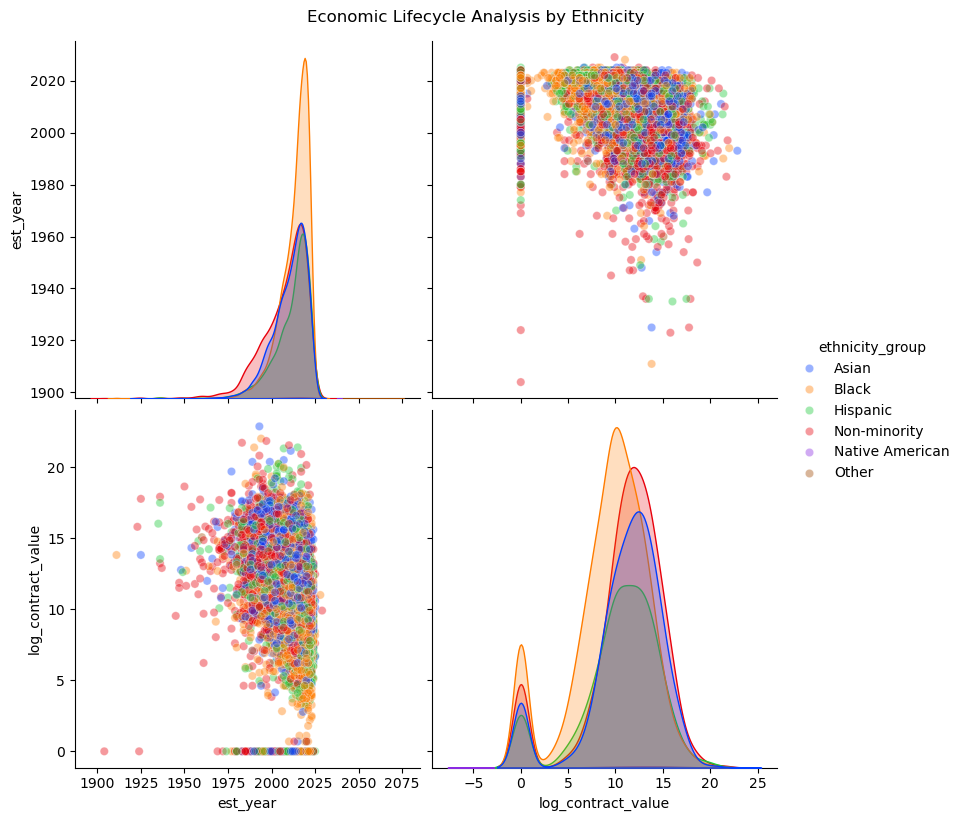

In [55]:
# creating a new subset pairing the numeric data
# log-transform the contract as before due to extreme outliers
df_pair = df_subset[['est_year', 'largest_value_of_contract',  'ethnicity_group']].copy()
df_pair['log_contract_value'] = np.log1p(df_pair['largest_value_of_contract'])

#Creating the Pair Plot
sns.pairplot(df_pair[['est_year', 'log_contract_value', 'ethnicity_group']], 
             hue='ethnicity_group', 
             palette='bright', #using bright colors to see different ethnic groups
             height=4,
             diag_kind='kde', #Using kde to show the distribution on the diagonal
             plot_kws={'alpha': 0.4}) #Transparent dots help to see overlap

plt.suptitle('Economic Lifecycle Analysis by Ethnicity', y=1.02)
plt.show()

## Analysis of Business Registration and Contract Distribution

### The 1980s Policy Pivot and Registration Surge
The longitudinal analysis reveals a stark contrast between pre-1980 and post-1980 registration trends. Prior to the 1980s, the registry was dominated by Non-minority business owners. However, following the introduction of Executive Order 50 and subsequent M/WBE legislation, there was a universal surge in registrations across all ethnic groups. This indicates that the legislation acted as a successful catalyst for diversifying the city’s vendor pool, moving it from a homogenous set of legacy businesses to a multi-ethnic ecosystem.

### Ethnicity and Entry-Level Economic Disparity
A notable pattern emerges when examining the relationship between the year of establishment and contract value. Asian business owners appear to enter the market with relatively higher initial contract values. This suggests a potential concentration in high-value industries or a different capitalization model upon entry.

### Volume vs. Value: The Black Business Ownership Gap
While the data shows that Black business owners represent a significantly larger portion of the total registrations (Volume), they are disproportionately represented in the lower contract value ranges. This highlights a critical "Volume-Value Gap": high participation rates do not currently correlate with high-value contract awards for this group, pointing to a potential area for targeted policy intervention to support business scaling.

### Hispanic Market Penetration
The distribution for Hispanic business owners (represented by the green dots in the scatter plot) is particularly unique. Despite having a lower total number of businesses than other major minority groups, Hispanic firms appear at almost all contract value levels. This "vertical" distribution suggests that Hispanic-owned firms are successfully competing across a wide range of contract sizes, from small-scale service agreements to high-value city contracts.

Creating a table showing the typical contract size for each ethnic group. Since the contract value data is highly skewed, with the mean of about 6 million vs the median of 67k, the median provides a more accurate picture of the dataset's common values.

In [56]:
#Creating a summary table grouped by ethnicity
#Using the subset of the NYC small business data to find out the largest value of contracts.
contract_stats = df_subset.groupby('ethnicity_group')['largest_value_of_contract'].agg(
    ['count', 'mean', 'median', 'std', 'max']
).sort_values(by='median', ascending=False)

#Formatting for better readability
print("Contract Value Distribution by Ethnicity Group:")
display(contract_stats.style.format("${:,.2f}"))

Contract Value Distribution by Ethnicity Group:


,count,mean,median,std,max
ethnicity_group,,,,,
Other,$4.00,"$3,195,811.25","$3,382,122.50","$2,453,080.94","$6,000,000.00"
Native American,$15.00,"$3,577,416.94","$223,750.00","$8,236,784.80","$31,966,275.10"
Asian,"$2,372.00","$7,425,681.41","$134,670.21","$179,495,014.08","$8,500,000,000.00"
Non-minority,"$2,760.00","$6,928,183.95","$130,948.00","$95,848,444.16","$3,047,745,498.00"
Hispanic,"$1,925.00","$6,215,030.47","$65,000.00","$68,686,967.82","$1,939,219,200.00"
Black,"$3,357.00","$3,320,344.84","$22,800.00","$72,550,045.65","$3,600,000,000.00"


### Visualizing the Typical Contract Values

C:\Users\paula.iman\AppData\Local\Temp\6\ipykernel_13600\2063059199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df_subset, x='ethnicity_group', y='largest_value_of_contract', palette='Set2')


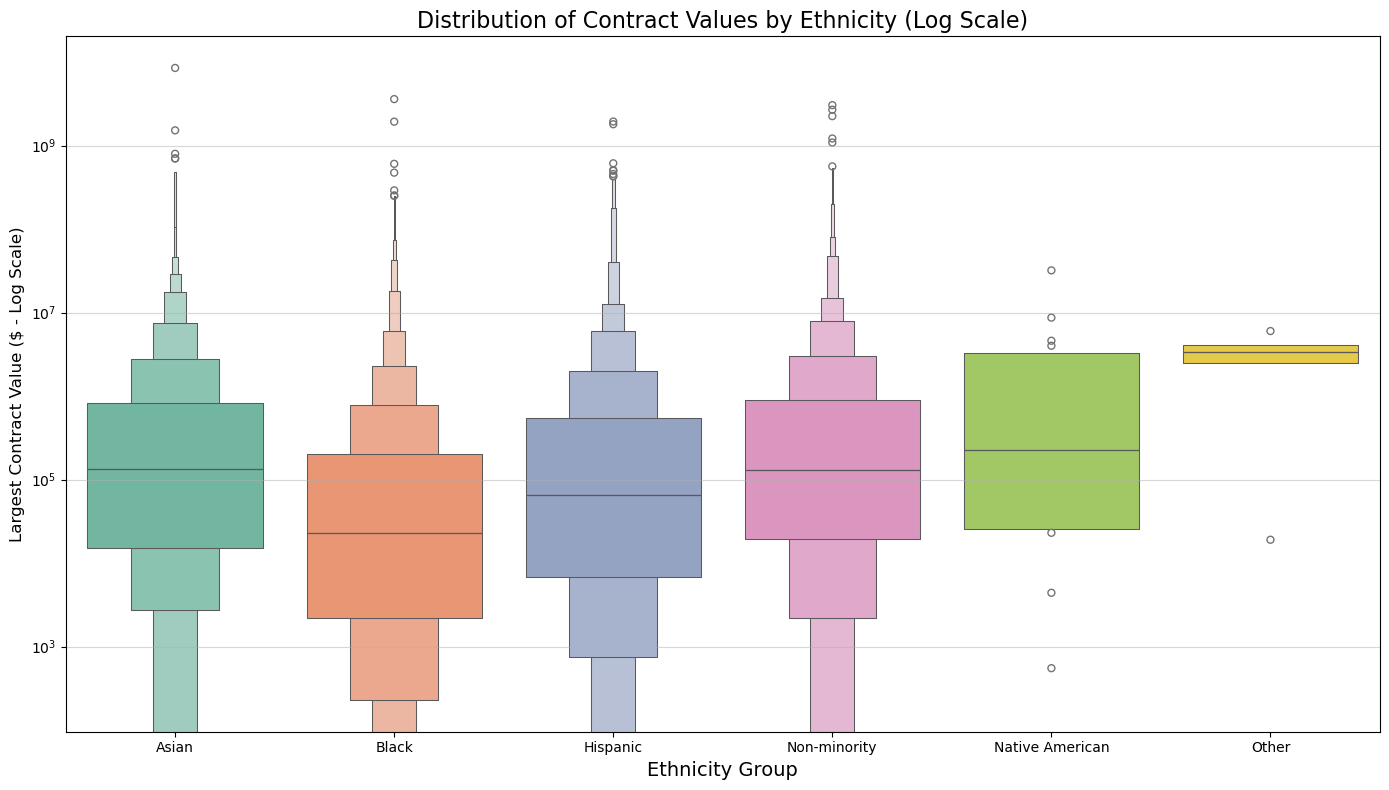

In [57]:
#import seaborn as sns
#import matplotlib.pyplot as plt
#The packages were imported previously

plt.figure(figsize=(14,8))

#Creating the plot and using boxenplot for this visualization.
# Using 'viridis' or a custom palette to distinguish groups
sns.boxenplot(data=df_subset, x='ethnicity_group', y='largest_value_of_contract', palette='Set2')

# Applying the Log scale to handle the $6M outliers vs $67k median
# Like earlier, it was hard to see the box due to extreme outliers. Therefore, using log scale to see the box.
plt.yscale('log')

# Formatting title and labels
plt.title('Distribution of Contract Values by Ethnicity (Log Scale)', fontsize=16)
plt.xlabel('Ethnicity Group', fontsize=14)

# Corrected: Adding the string argument to fix the previous TypeError
plt.ylabel('Largest Contract Value ($ - Log Scale)', fontsize=12)

plt.grid(True, axis='y', linestyle='-', alpha=0.5)
#plt.xticks(rotation=45) #this was not needed since there is enough space to see all the names.

plt.tight_layout()
plt.show()

The comparison shows that Asian- and Non-Minority-owned businesses have higher average and median positions than Black- and Hispanic-owned businesses. On average, their contract values are more consistently distributed in the higher tiers, showing that these businesses secure larger contracts.

Black- and Hispanic-owned businesses show a lower median value line, confirming that they generally have lower contract values, while a select few reach multi-million-dollar levels. 

Native Americans and Other ethnicities have the highest median contract value, even if they are the smallest groups in the dataset. This suggest that these groups may be concentrated in specialized, high-overhead industries where the "typical" entry-level contract is larger than average. 

## 5.	Regression and Classification 

a.	Regression Analysis

i.	Select an appropriate regression model based on the variable selected.  
ii.	Run the regression model and evaluate it with the performance metrics you’ve learned  
iii.	Interpret your result 
iv.	You may also want to check for multicollinearity or analyze residual to check your assumptions (Optional) 


I am using a logistic regression model to determine the probability that a company will renew its business license. 
After using both 'ethnicity' and 'gender_estimate', the latter provided more reliable results. Therefore, using the gender of the business owner to predict the probability of renewal of the business license. 

In [58]:
#Importing needed package
import statsmodels.api as sm

# Preparing the features and if renewed as the target
df_reg = df_subset.copy()
df_reg['has_renewed'] = df_reg['renew_year'].notna().astype(int)
df_reg['log_contract'] = np.log1p(pd.to_numeric(df_reg['largest_value_of_contract'], errors='coerce').fillna(0))

# Using ethnicity and gender_estimate and preparing dummy variables for them.
# Dropping first variable - 'Asian' or 'Female', to serve as a baseline
gen_dummies = pd.get_dummies(df_reg['gender_estimate'], prefix='Gen', drop_first=True, dtype=int)

# Combining the features
x = pd.concat([df_reg[['est_year', 'log_contract']], gen_dummies], axis=1)
y = df_reg['has_renewed']

# Since in the beginning the values had non-numeric values or NaNs, making sure they are removed.
combined = pd.concat([x, y], axis=1).dropna()
x_final = combined.drop(columns=['has_renewed'])
y_final = combined['has_renewed']

x_final = sm.add_constant(x_final)

# Running the model and printing out the result
model_expanded = sm.Logit(y_final.astype(float), x_final.astype(float)).fit()
print(model_expanded.summary())

Optimization terminated successfully.
         Current function value: 0.388102
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            has_renewed   No. Observations:                10432
Model:                          Logit   Df Residuals:                    10424
Method:                           MLE   Df Model:                            7
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.4358
Time:                        14:42:32   Log-Likelihood:                -4048.7
converged:                       True   LL-Null:                       -7175.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.6571      5.750      1.158      0.247      -4.613      17.927
est_year

This model has a Pseudo R-squared of 0.4358. Roughly 43% of the variation in whether a business renews its license depends on the chosen variables: gender and largest contract value.
Gender variables have highly significant p-values. The Gen_male coefficient is 1.80, indicating that if the owner is male, the odds of renewing the business license are significantly higher. 
The Gen_female coefficient is -2.88, indicating that if the owner is female, the odds of renewing the business licence are significantly lower than the baseline. 
The categories for mostly female and mostly male follow the same direction, supporting the results.

The contract value coefficient is 0.042, indicating that as contract value increases, the probability of the company renewing its license increases.
However, the establishment year is insignificant, giving a p-value of 0.242 (>0.05). The establishment year does not help determine if the business renews its license. 

Based on the results, it is safe to say there is a gender gap in business renewal. Even though the number of female-owned businesses was growing faster, they seem less likely to renew their certification than male-owned businesses.


In [59]:
#Creating a confusion matrix to evaluate the model accuracy.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# generating predicted probabilities
y_pred_prob = model_expanded.predict(x_final.astype(float))

# Converting probabilities to binary predictions with threshold 0.5.
y_pred = (y_pred_prob > 0.5).astype(int)

#Confusion Matrix
cm = confusion_matrix(y_final, y_pred, labels=[0, 1])
#Creating readable DataFrame
cm_df = pd.DataFrame(cm,
                     index=['Actual Not Renewed (0)', 'Actual Renewed (1)'],
                     columns=['Predicted Not Renewed (0)', 'Predicted Renewed (1)'])

print("Confusion Matrix:")
print(cm_df)

print("\nClassification Report")
print(classification_report(y_final, y_pred))

#Overall accuracy
print(f"Overall Model Accuracy: {accuracy_score(y_final, y_pred):.2%}")

Confusion Matrix:
                        Predicted Not Renewed (0)  Predicted Renewed (1)
Actual Not Renewed (0)                       4611                   1141
Actual Renewed (1)                            570                   4110

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      5752
           1       0.78      0.88      0.83      4680

    accuracy                           0.84     10432
   macro avg       0.84      0.84      0.84     10432
weighted avg       0.84      0.84      0.84     10432

Overall Model Accuracy: 83.60%


Precision for renewals is 0.78. The model correctly predicts renewals 78% of the time. The model also predicted 88% of the renewals out of all renewed business licenses. 
F1-scores show 0.84 for non-renewals and 0.83 for renewals. Since the amounts are close, the model is stable. 

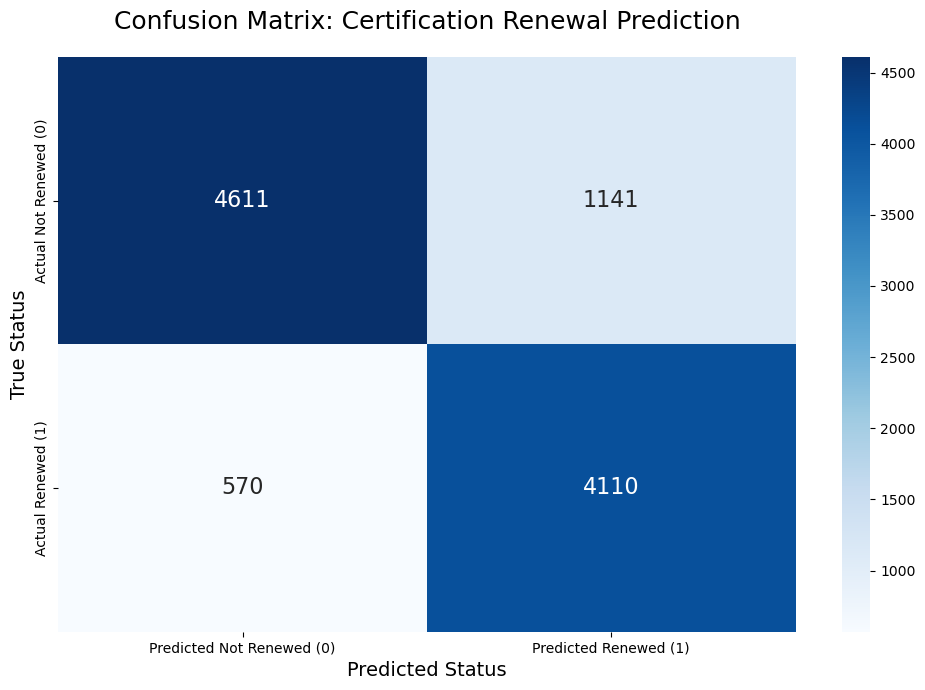

In [60]:
#Creating a heatmap to visualize the confusion matrix
#Using data from the confusion matrix above.
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})

# Adding titles and labels
plt.title('Confusion Matrix: Certification Renewal Prediction', fontsize=18, pad=20)
plt.ylabel('True Status', fontsize=14)
plt.xlabel('Predicted Status', fontsize=14)
plt.tight_layout()

# Save the plot
plt.savefig('confusion_matrix_heatmap.png')


b. Classification Model

i. Select an appropriate classification model based on the variable selected.  
ii. Conduct the classification analysis and evaluate it with multiple metrics to provide a fuller picture of performance.  
iii. Interpret your result

I am looking into whether industry sector and contract value influence whether the businesses are located in one of the 10 largest cities or are "spread out" evenly across all the cities. 

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import pandas as pd
# 
# Preparing the target by identifying the top 10 Cities and printing out the largest business areas.
top_10_list = df_subset['city'].value_counts().nlargest(10).index.tolist()
df_subset['is_top_10_city'] = df_subset['city'].apply(lambda x: 1 if x in top_10_list else 0)
print(f"Data has {df_subset['city'].nunique()} cities")
print(f"The 10 cities with the most businesses are: {top_10_list}")

Data has 1171 cities
The 10 cities with the most businesses are: ['New York', 'Brooklyn', 'Bronx', 'Staten Island', 'Jamaica', 'Long Island City', 'Astoria', 'Flushing', 'Yonkers', 'Valley Stream']


In [62]:
# Creating features
# Convert contract value to numeric and apply Log Transformation
df_subset['contract_numeric'] = pd.to_numeric(df_subset['largest_value_of_contract'], errors='coerce').fillna(0)
df_subset['log_contract'] = np.log1p(df_subset['contract_numeric'])

# Creating Feature Matrix (X) and Target (y)
# We now include the numeric 'log_contract' alongside categorical dummies
x_cats = pd.get_dummies(df_subset[['naics_sector']], drop_first=True)
x = pd.concat([df_subset[['log_contract']], x_cats], axis=1)
y = df_subset['is_top_10_city']

#Train/Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#Initializing and Training Logistic Regression
log_clf = LogisticRegression(max_iter=2000, solver='liblinear')
log_clf.fit(x_train, y_train)

# Prediction
y_pred = log_clf.predict(x_test)
y_prob = log_clf.predict_proba(x_test)[:, 1]

# Printing out the evaluation
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

logit_model = sm.Logit(y.astype(float), x.astype(float)).fit()
print(logit_model.summary())

Confusion Matrix
[[434 541]
 [340 772]]

Classification Report
              precision    recall  f1-score   support

           0       0.56      0.45      0.50       975
           1       0.59      0.69      0.64      1112

    accuracy                           0.58      2087
   macro avg       0.57      0.57      0.57      2087
weighted avg       0.58      0.58      0.57      2087

ROC-AUC Score: 0.6085
Optimization terminated successfully.
         Current function value: 0.678720
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         is_top_10_city   No. Observations:                10433
Model:                          Logit   Df Residuals:                    10413
Method:                           MLE   Df Model:                           19
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                 0.01776
Time:                        14:42:44   Log-Likelihood:                -7081.1
converged:  

This model identified 69% of the businesses located in the top 10 cities (recall (1) = 0.69). This shows that the model recognizes certain economic features and locates them in the largest cities. However, the recall is only 0.59, indicating that the business, which appears to be a big-city operation, is actually in a smaller area. The model is challenged. The ROC_AUC Score of 0.6085 indicates that the model is somewhat informative and not pure guessing (just guessing would be 0.5). 

The R-squared of 0.01776, or about 1.8%, tells us that this model explains only a small portion of why businesses locate where they do. This supports the idea that businesses are scattered across cities regardless of their sector or the large contracts they have. However, the small p-value indicates that the findings are significant even though they do not explain much. 

In [63]:
# Finding out what sectors pull mostly to the big cities. 
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': log_clf.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 5 Economic Factors Pulling Toward Top 10 Cities:")
print(feature_importance.head(5))

Top 5 Economic Factors Pulling Toward Top 10 Cities:
                                              Feature  Coefficient
9   naics_sector_Management of Companies and Enter...     0.019100
0                                        log_contract    -0.041388
7      naics_sector_Health Care and Social Assistance    -0.066581
12  naics_sector_Other Services (except Public Adm...    -0.096537
3    naics_sector_Arts, Entertainment, and Recreation    -0.105870


The only sector with a positive coefficient is management. It is the only sector pulling the location into the 10 largest cities. The other sectors have negative coefficients, indicating they are more likely to be located in smaller business areas. The contract size coefficient indicates that the businesses with the largest contracts are more likely to be located in the surrounding smaller city areas. Also, health care and other services, as well as arts and entertainment, are more likely to be located in the surrounding smaller city areas. 
Even though the coefficients are small, they are negative, meaning that the services are decentralized. Given a small LLR p-value, the result is significant and a statistically "real" phenomenon. 

## 6.	Advanced Analysis Techniques 

a.	Clustering Analysis  
i.	Select an appropriate clustering method for your data, and consider including dimensionality reduction (e.g., PCA) to visualize the clusters especially in high-dimensional spaces.   
ii.	Evaluate the model and interpret the grouping of data based on the result  


I intend to use the geographic coordinates and business-sector variables in the data to identify the locations of the different business clusters. First, I will use K-Means clustering to identify the main clusters, and then use PCA to simplify them. 
To begin with, the coordinate data needs to be cleaned, and the optimal number of clusters determined using the Elbow method. 

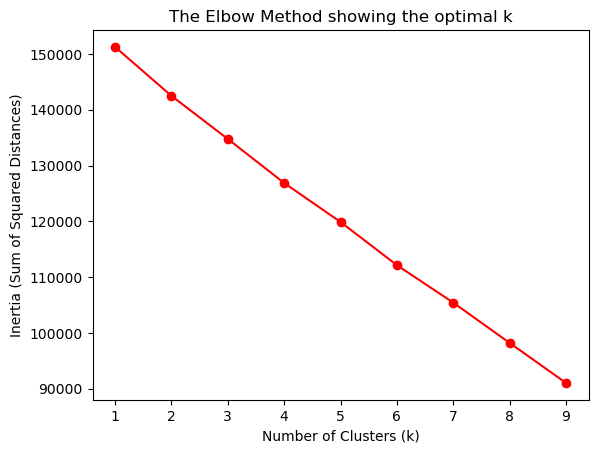

In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Data cleaning
# Filter rows that have both latitude and longitude
df_clust = df.dropna(subset=['latitude', 'longitude', 'naics_sector']).copy()

# Convert coordinates to numeric values.
df_clust['latitude'] = pd.to_numeric(df_clust['latitude'], errors='coerce')
df_clust['longitude'] = pd.to_numeric(df_clust['longitude'], errors='coerce')
df_clust = df_clust.dropna(subset=['latitude', 'longitude'])

# Creating features using One-Hot Encoding for Sectors
x_sectors = pd.get_dummies(df_clust['naics_sector'])
x_coords = df_clust[['latitude', 'longitude']]
x_combined = pd.concat([x_coords, x_sectors], axis=1)

#Scaling - with standard scaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_combined)

#Finding Optimal Clusters-Elbow Method.
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)

# Plot Elbow Curve
plt.plot(K, inertia, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('The Elbow Method showing the optimal k')
plt.show()

#Apply K-Means (Assuming k=4 for this example)
k_best = 4
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(x_scaled)

#PCA for Visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
df_clust['pca1'] = x_pca[:, 0]
df_clust['pca2'] = x_pca[:, 1]

In [65]:
# See which sector dominates each cluster
print(df_clust.groupby('cluster')['naics_sector'].agg(lambda x: x.value_counts().index[0]))

cluster
0    Professional, Scientific, and Technical Services
1                                Educational Services
2                                         Information
3                                        Construction
Name: naics_sector, dtype: object


In [66]:
#Summarizing the main 4 clusters found.  
#Re-create the necessary columns within the clustering dataframe
# Convert contract value to numeric for averaging
df_clust['contract_numeric'] = pd.to_numeric(df_clust['largest_value_of_contract'], errors='coerce').fillna(0)

#Defining the summary function
def summarize_4_clusters(df):
    summary_data = []
    
    for i in range(4):  # For4 clusters
        cluster_data = df[df['cluster'] == i] #Using the original df 
        total = len(cluster_data)
        
        if total == 0: continue
            
        # Top Sector in this cluster
        top_sector = cluster_data['naics_sector'].value_counts().index[0]
        sector_count = cluster_data['naics_sector'].value_counts().iloc[0]
        sector_pct = (sector_count / total) * 100
        
        # Average Contract Value
        avg_contract = cluster_data['contract_numeric'].mean()
        
        # Top City in this cluster
        top_city = cluster_data['city'].value_counts().index[0]
        
        summary_data.append({
            'Cluster #': i,
            'Business Count': total,
            'Primary Industry': f"{top_sector} ({sector_pct:.1f}%)",
            'Avg Contract': f"${avg_contract:,.2f}",
            'Main Location': top_city
        })
        
    return pd.DataFrame(summary_data)

#Printing the Summary
cluster_profile = summarize_4_clusters(df_clust)
print("\nDetailed Profile of the 4 Business Clusters\n")
print(cluster_profile.to_string(index=False))


Detailed Profile of the 4 Business Clusters

 Cluster #  Business Count                                          Primary Industry  Avg Contract Main Location
         0            2059 Professional, Scientific, and Technical Services (100.0%) $5,948,788.82      New York
         1            2418                              Educational Services (21.3%) $1,087,358.32      Brooklyn
         2             182                                      Information (100.0%)   $966,496.13      New York
         3            2217                                      Construction (71.4%) $9,401,760.61      Brooklyn


Main clusters are located in New York and Brooklyn. However, the percentage of educational services in its cluster is 21%. The cluster must also include other services. 

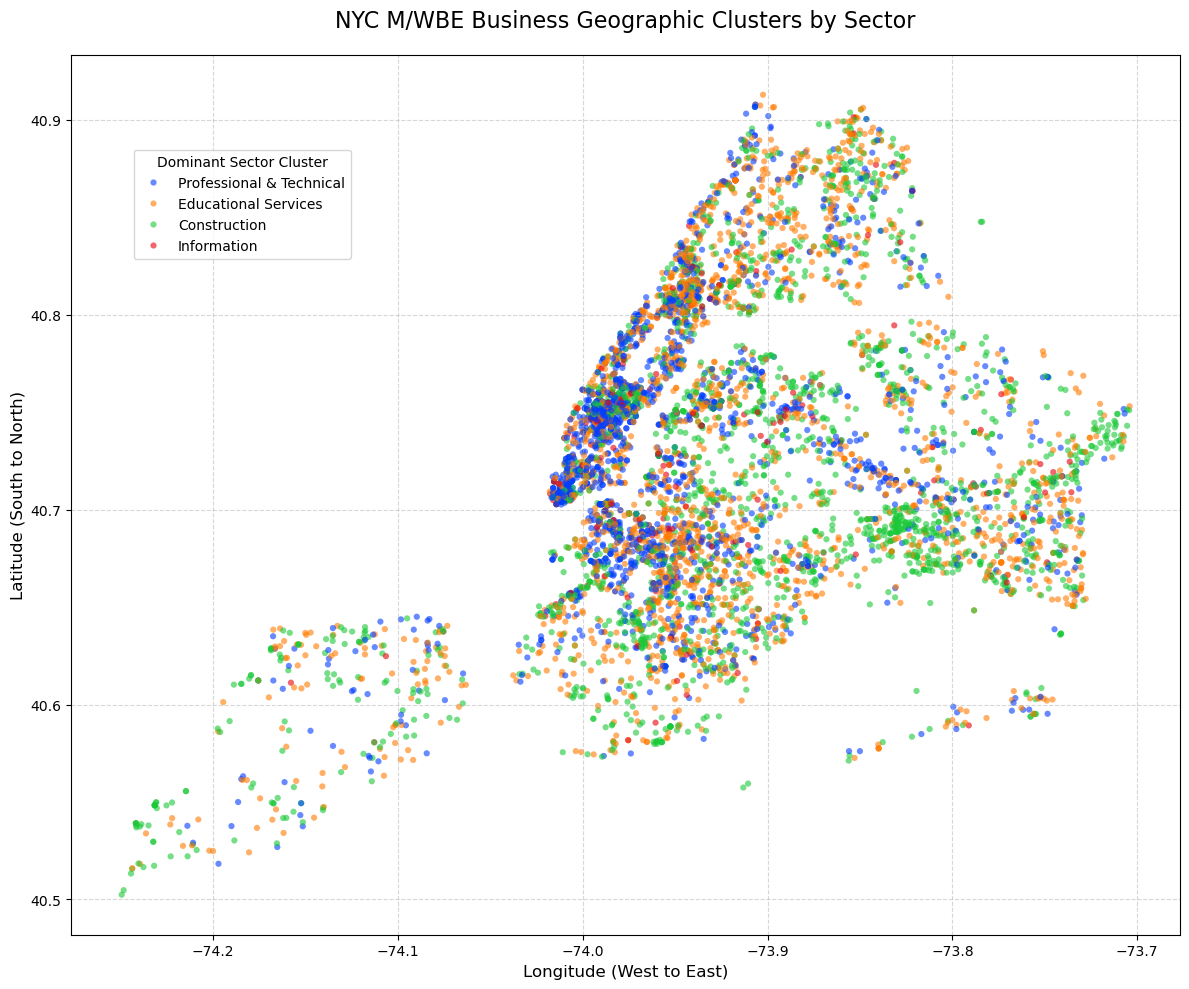

In [67]:
#I enjoy looking at maps. I want to see how the clusters are located in map shape using the coordinates.
#Ensure coordinates are numeric
df_clust['latitude'] = pd.to_numeric(df_clust['latitude'], errors='coerce')
df_clust['longitude'] = pd.to_numeric(df_clust['longitude'], errors='coerce')

#Mapping the cluster results to their descriptive labels for simplify the output.
cluster_labels = {
    0: "Professional & Technical",
    1: "Educational Services",
    2: "Information",
    3: "Construction"
}
df_clust['Cluster Label'] = df_clust['cluster'].map(cluster_labels)

# Creating the Visualization using scatterplot and the coordinates as axes.
plt.figure(figsize=(12, 10))

#Longitude (X) and Latitude (Y) to shape out the NYC geography
sns.scatterplot(
    data=df_clust, 
    x='longitude', 
    y='latitude', 
    hue='Cluster Label', 
    palette='bright', # bright colors seem fit for a busy plot
    alpha=0.6, #fading out the dots to see the different colors better. Manhattan and Brooklyn are very saturated. 
    s=20, 
    edgecolor='none'
)

#Formatting to make it look like a Map
plt.title('NYC M/WBE Business Geographic Clusters by Sector', fontsize=16, pad=20)
plt.xlabel('Longitude (West to East)', fontsize=12)
plt.ylabel('Latitude (South to North)', fontsize=12)

# Positioning Legend in an empty spot
plt.legend(title='Dominant Sector Cluster', bbox_to_anchor=(0.05, 0.90), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The "map" clearly shows Lower Manhattan and Brooklyn as the main hubs for all the clusters. The green construction spots are spread across most areas, as are the yellow education services. 

b.	Machine Learning approach to Regression or Classification  
i.	Apply a regression or classification model using machine learning approach. You can use the same set of variables from requirement number 5.  
ii.	Evaluate the model performance metrics and interpret the results 


In [68]:
#Using random forest and using the same variables as in the task #5
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import pandas as pd
import numpy as np

#Identify Top 10 Cities and Create Target
top_10_cities = df_subset['city'].value_counts().nlargest(10).index.tolist()
df_subset['is_top_10_city'] = df_subset['city'].apply(lambda x: 1 if x in top_10_cities else 0)

#Prepare Features (One-Hot Encoding)
df_subset['contract_numeric'] = pd.to_numeric(df_subset['largest_value_of_contract'], errors='coerce').fillna(0)
df_subset['log_contract'] = np.log1p(df_subset['contract_numeric'])

#Categorical sectors, one-hot encoding
x_cats = pd.get_dummies(df_subset[['naics_sector']], drop_first=True)
x = pd.concat([df_subset[['log_contract']], x_cats], axis=1)
y = df_subset['is_top_10_city']

#Train/Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#Initialize and Train Random Forest, 100 individual decision treees
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)

#Creating Predictions
y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[:, 1]

#Printing out evaluation
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")



Confusion Matrix

[[404 571]
 [328 784]]

Classification Report

              precision    recall  f1-score   support

           0       0.55      0.41      0.47       975
           1       0.58      0.71      0.64      1112

    accuracy                           0.57      2087
   macro avg       0.57      0.56      0.55      2087
weighted avg       0.57      0.57      0.56      2087

ROC-AUC Score: 0.5973


The Random Forest has an overall accuracy 57%, close to the previous Logistic regression. It identifies even more businesses in big cities. The recall of 0.71 shows that random forests outperform logistic regression, achieving 0.69.
The precision of 0.58 and 571 false positives indicates that the Random Forest model struggles to predict correctly when the business is not located in one of the top 10 cities. But the earlier cluster analysis showed that, for example, the construction industry is spread all around the smaller areas as well. Even a random forest cannot predict business decentralization, because "big city kind of businesses", businesses with high volume, are spreading to smaller business areas as well. 
ROC of 0.597 indicates that the prediction is better than a coin flip (0.5). However, there is a high degree of geographic freedom, and business locations are not dictated by contract size or business sector. 
Overall, random forests were better at capturing "big city" businesses, whereas logistic regression was slightly more balanced in its errors. 